In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Çox xətti reqressiya - Multiple Linear Regression

In [3]:
stud = pd.read_csv("students.csv")

stud.head()

,score,iq,hours,gender
0,10.00,119,21,0
1,10.00,115,21,0
2,9.91,114,21,0
3,9.83,113,21,0
4,9.81,114,21,0


In [4]:
model = smf.ols(formula='score ~ iq + hours', data=stud).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     469.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.37e-72
Time:                        00:30:44   Log-Likelihood:                -158.01
No. Observations:                 182   AIC:                             322.0
Df Residuals:                     179   BIC:                             331.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.3953      1.374    -12.656      0.0

## Fərziyyələrin yoxlanması

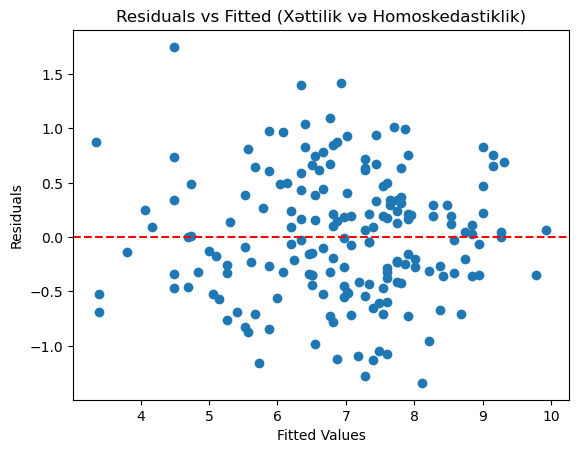

In [5]:
# 1. Xəttilik və 5. Homoskedastiklik
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Xəttilik və Homoskedastiklik)')
plt.show()

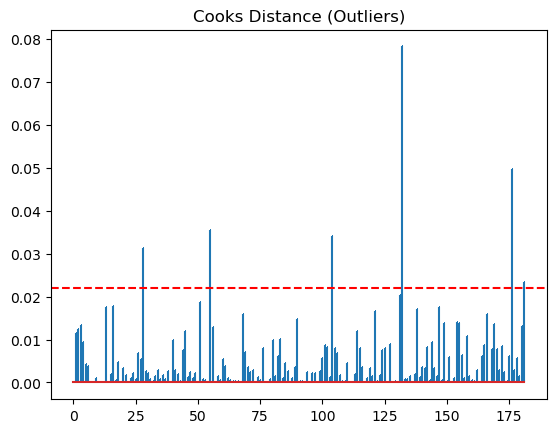

In [6]:
# 2. Outliers (Cook's Distance)
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=4 / len(stud), color='red', linestyle='--')
plt.title('Cooks Distance (Outliers)')
plt.show()

In [7]:
# 3. Errorların müstəqilliyi (Durbin-Watson)
dw = durbin_watson(model.resid)
print(f"Durbin-Watson: {dw}")

Durbin-Watson: 1.779333233097246


In [8]:
# 4. Multikolinearlıq (VIF)
X = stud[['iq', 'hours']]
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

  feature          VIF
0   const  1017.376273
1      iq     1.042853
2   hours     1.042853


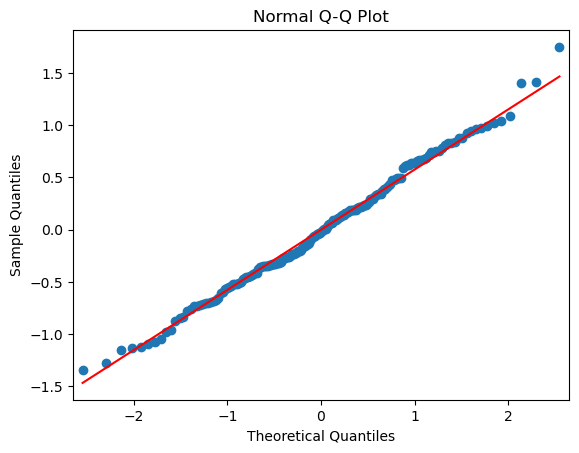

In [9]:
# 6. Normal Qalıqlar (Q-Q Plot və Shapiro-Wilk)
sm.qqplot(model.resid, line='s')
plt.title('Normal Q-Q Plot')
plt.show()

In [10]:
shapiro_test = stats.shapiro(model.resid)
print(f"Shapiro-Wilk test: {shapiro_test}")

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.9934334820468799), pvalue=np.float64(0.592770070194317))
